<h1>Zadanie 3</h1>

1. Stiahnite si dátovú množinu Sonar.

2. Načítajte dáta z CSV súboru sonar.all-data a vytvorte numpy polia pre trénovacie a testovacie dáta (70% trénovacích a 30% testovacích príkladov)

3. Naučte a otestujte doprednú neurónovú sieť. Vyskúšajte rôzny počet skrytých vrstiev a rôzny počet neurónov v skrytých vrstvách. Váhy inicializujte podľa Glorot schémy.

4. Vyskúšajte rôzne optimalizačné metódy (SGD, Adagrad, RMSprop, Adam).

5. Vytvorte prehľadovú tabuľku s presnosťou na testovacích dátach pre otestované kombinácie parametrov a optimalizačných metód. Pre najlepšie nastavenie vykreslite priebeh chybovej funkcie počas učenia.

In [1]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

2025-10-22 10:09:53.114119: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-22 10:09:55.411646: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151) 
  
# data (as pandas dataframes) 
X = connectionist_bench_sonar_mines_vs_rocks.data.features 
y = connectionist_bench_sonar_mines_vs_rocks.data.targets 
  
# metadata 
print(connectionist_bench_sonar_mines_vs_rocks.metadata) 
  
# variable information 
print(connectionist_bench_sonar_mines_vs_rocks.variables) 


{'uci_id': 151, 'name': 'Connectionist Bench (Sonar, Mines vs. Rocks)', 'repository_url': 'https://archive.ics.uci.edu/dataset/151/connectionist+bench+sonar+mines+vs+rocks', 'data_url': 'https://archive.ics.uci.edu/static/public/151/data.csv', 'abstract': 'The task is to train a network to discriminate between sonar signals bounced off a metal cylinder and those bounced off a roughly cylindrical rock.', 'area': 'Physics and Chemistry', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 208, 'num_features': 60, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': None, 'dataset_doi': '10.24432/C5T01Q', 'creators': ['Terry Sejnowski', 'R. Gorman'], 'intro_paper': None, 'additional_info': {'summary': 'The file "sonar.mines" contains 111 patterns obtained by bouncing sonar signals off a metal cylinder at various a

In [4]:
X

,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,...,Attribute51,Attribute52,Attribute53,Attribute54,Attribute55,Attribute56,Attribute57,Attribute58,Attribute59,Attribute60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0232,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0125,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0033,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0241,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0203,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0051,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0155,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0042,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048


In [5]:
y

,class
0,R
1,R
2,R
3,R
4,R
...,...
203,M
204,M
205,M
206,M


In [6]:
from sklearn.model_selection import train_test_split
import numpy as np

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123, stratify=y
)

In [8]:
y.shape #-> prerobit na 1d

(208, 1)

In [9]:
x_train = x_train.to_numpy()
x_test = x_test.to_numpy()
y_train = np.ravel(y_train.to_numpy())
y_test = np.ravel(y_test.to_numpy())

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [11]:
y_train = np.where(y_train == 'M', 1, 0).astype('float32')
y_test = np.where(y_test == 'M', 1, 0).astype('float32')

In [12]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [13]:
print(y_train.dtype)

float32


In [14]:
print(x_train.dtype)

float32


In [15]:
x_train

array([[ 0.53480256, -0.34663203,  0.41487616, ..., -0.46825176,
         0.08957395, -0.43876693],
       [-0.37411976, -0.39729264, -0.7835601 , ...,  3.0646229 ,
         0.81665003, -0.8342806 ],
       [-0.6890928 , -0.5207778 , -0.86031944, ..., -0.33465567,
        -0.67055106, -0.36343098],
       ...,
       [-0.792584  , -0.6569282 ,  0.03107942, ..., -0.40887573,
         1.1306148 ,  0.46526438],
       [-0.10414282, -0.01100558,  0.16974147, ..., -0.809664  ,
        -0.40615976, -0.19392511],
       [-0.8240813 , -0.9292289 , -0.781084  , ..., -0.3791877 ,
        -0.40615976, -0.5329369 ]], dtype=float32)

In [16]:
!pip install tensorflow

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import initializers

In [53]:
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras import regularizers

In [54]:
def create_model(hidden_layers, neurons, optimizer_class, lr, input_dim):
    optimizer = optimizer_class(learning_rate=lr)
    model = Sequential()
    for layer_index in range(hidden_layers):
        if layer_index == 0: 
            model.add(Dense(neurons, input_dim=input_dim, activation='relu', kernel_initializer=initializers.glorot_normal(seed=1234), bias_initializer=initializers.Zeros(), kernel_regularizer=regularizers.l2(0.01)))        
        else:
            model.add(Dense(neurons, activation='relu', kernel_initializer=initializers.glorot_normal(seed=1234), bias_initializer=initializers.Zeros(), kernel_regularizer=regularizers.l2(0.01)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [55]:
hidden_layers_list = [1, 2]
neurons_list = [16, 32]
optimizers = {
    'SGD': (SGD, 0.01),
    'Adagrad': (Adagrad, 0.01),
    'RMSprop': (RMSprop, 0.001),
    'Adam': (Adam, 0.001)
}

In [56]:
results = []
input_dim = 60

In [57]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',   
    patience=5,           
    restore_best_weights=True  
)

In [58]:
for layers in hidden_layers_list:
    for neurons in neurons_list:
        for optimizer_name, (optimizer_class, lr) in optimizers.items():
            model = create_model(layers, neurons, optimizer_class, lr, input_dim=input_dim)
            history = model.fit(x_train, y_train, epochs=10, batch_size=8, verbose=1, validation_split=0.2, callbacks=[early_stop])
            test_accuracy = model.evaluate(x_test, y_test, verbose=1)[1] #[loss][acc]
            results.append([layers, neurons, optimizer_name, test_accuracy, history])

Epoch 1/10
 1/15 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7500 - loss: 1.0236

/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/opt/conda/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4655 - loss: 1.1527 - val_accuracy: 0.3103 - val_loss: 1.4380
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5259 - loss: 1.0434 - val_accuracy: 0.3448 - val_loss: 1.3548
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.5690 - loss: 0.9687 - val_accuracy: 0.3103 - val_loss: 1.2842
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6379 - loss: 0.9162 - val_accuracy: 0.3103 - val_loss: 1.2347
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6293 - loss: 0.8760 - val_accuracy: 0.3103 - val_loss: 1.1869
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6638 - loss: 0.8443 - val_accuracy: 0.4138 - val_loss: 1.1436
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6724 - loss: 0.8146 - val_accuracy: 0.4138 - val_loss: 1.1069
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6983 - loss: 0.7917 - val_accuracy: 0.5172 - val_loss: 1.

In [59]:
import pandas as pd
df_results = pd.DataFrame(results, columns=['Layers', 'Neurons', 'Optimizer', 'Test_Accuracy', 'History'])
df_results = df_results.sort_values(by='Test_Accuracy', ascending=False)

In [60]:
print(df_results[['Layers', 'Neurons', 'Optimizer', 'Test_Accuracy']])

    Layers  Neurons Optimizer  Test_Accuracy
1        1       16   Adagrad       0.714286
15       2       32      Adam       0.634921
7        1       32      Adam       0.619048
14       2       32   RMSprop       0.603175
5        1       32   Adagrad       0.587302
12       2       32       SGD       0.571429
2        1       16   RMSprop       0.555556
3        1       16      Adam       0.555556
11       2       16      Adam       0.555556
13       2       32   Adagrad       0.555556
0        1       16       SGD       0.539683
10       2       16   RMSprop       0.539683
4        1       32       SGD       0.523810
6        1       32   RMSprop       0.492063
9        2       16   Adagrad       0.460317
8        2       16       SGD       0.444444


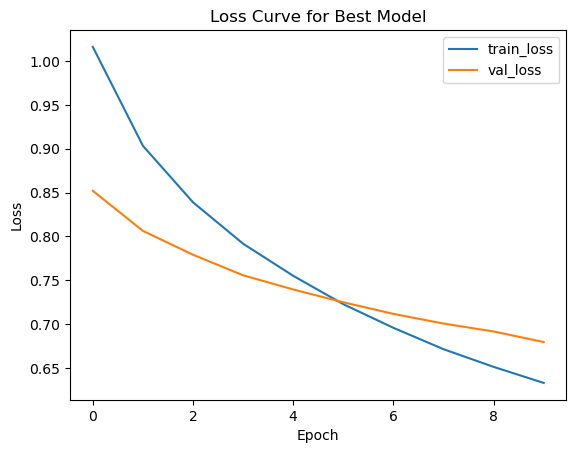

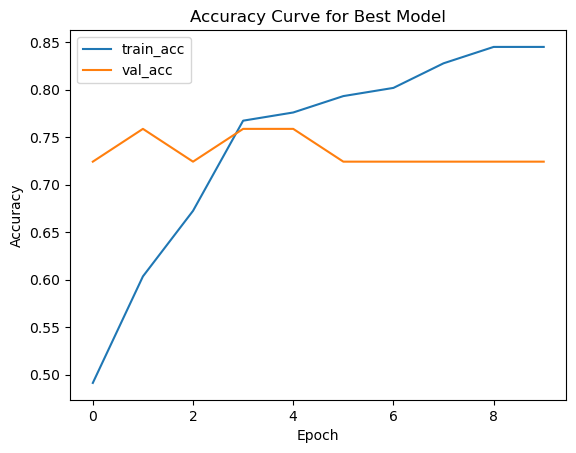

In [61]:
import matplotlib.pyplot as plt

best_history = df_results.iloc[0]['History']

# loss
plt.plot(best_history.history['loss'], label='train_loss')
plt.plot(best_history.history['val_loss'], label='val_loss')
plt.title('Loss Curve for Best Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# accuracy 
plt.plot(best_history.history['accuracy'], label='train_acc')
plt.plot(best_history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve for Best Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# len optimiz

In [18]:
optimizers = {
    'SGD': SGD(0.01),
    'Adagrad': Adagrad(0.01),
    'RMSprop': RMSprop(0.001),
    'Adam': Adam(0.001)
}

2025-10-19 10:49:06.179919: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [19]:
test_accuracy = {}
histories = {}

In [20]:
for optimizer_name, optimizer in optimizers.items():
    model = Sequential()
    model.add(Dense(10, input_dim=60, activation='relu', kernel_initializer=initializers.glorot_normal(seed=1234), bias_initializer=initializers.Zeros()))
    model.add(Dense(1, activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)
    histories[optimizer_name] = history

    scores = model.evaluate(x_test, y_test, verbose=0)
    test_accuracy[optimizer_name] = scores[1]

Epoch 1/50


/opt/conda/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5259 - loss: 0.7268 - val_accuracy: 0.4828 - val_loss: 0.8006
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5431 - loss: 0.6993 - val_accuracy: 0.5172 - val_loss: 0.7826
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5690 - loss: 0.6766 - val_accuracy: 0.5172 - val_loss: 0.7669
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6121 - loss: 0.6571 - val_accuracy: 0.5517 - val_loss: 0.7519
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6207 - loss: 0.6409 - val_accuracy: 0.5862 - val_loss: 0.7378
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6552 - loss: 0.6271 - val_accuracy: 0.5517 - val_loss: 0.7236
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6983 - loss: 0.6136 - val_accuracy: 0.5517 - val_loss: 0.7079
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7069 - loss: 0.6019 - val_accuracy: 0.5517 - val_loss: 0.6968
Epoch 9/50
8/8

In [21]:
import pandas as pd
df = pd.DataFrame(list(test_accuracy.items()), columns=['optimizer', 'accuracy (test data)'])
df

,optimizer,accuracy (test data)
0,SGD,0.730159
1,Adagrad,0.777778
2,RMSprop,0.746032
3,Adam,0.777778


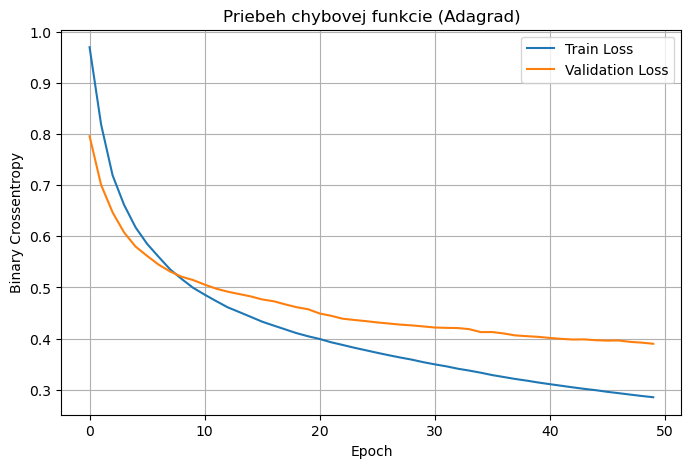

In [24]:
import matplotlib.pyplot as plt


best_opt = df.sort_values('accuracy (test data)', ascending=False).iloc[0]['optimizer']
#best_opt = 'Adagrad'
best_history = histories[best_opt]

plt.figure(figsize=(8,5))
plt.plot(best_history.history['loss'], label='Train Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.title(f'Priebeh chybovej funkcie ({best_opt})')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.grid(True)
plt.show()